In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from scipy.interpolate import RectBivariateSpline
from scipy.interpolate import CubicSpline

torch.set_default_dtype(torch.float64)

In [2]:
%run func_defs.ipynb

In [3]:
def pt_2d_interpolation(z, t, U, **kwargs):
    """
    PyTorch-compatible 2D interpolator using RectBivariateSpline.

    Parameters
    ----------
    z  : (nz+1,)           spatial grid  (strictly increasing)
    t  : (n_t_out,)        time grid     (strictly increasing)
    U  : (nz+1, n_t_out)   U[i, j] = solution at (z[i], t[j])
    **kwargs               passed to RectBivariateSpline
                           e.g. kx=3, ky=3, s=0  (cubic, exact)
                                kx=1, ky=1, s=0  (linear, exact)

    Returns
    -------
    interp : callable
        interp(z_q, t_q)           ->  U(z_q, t_q)
        interp(z_q, t_q, dx=1)     ->  dU/dz(z_q, t_q)
        interp(z_q, t_q, dy=1)     ->  dU/dt(z_q, t_q)
    """
    defaults = {'kx': 3, 'ky': 3, 's': 0}   # cubic exact-fit by default
    defaults.update(kwargs)

    rbs = RectBivariateSpline(
        z.cpu().numpy(),
        t.cpu().numpy(),
        U.cpu().numpy(),
        **defaults,
    )

    def interp(z_q, t_q, **ev_kwargs):
        z_q, t_q = torch.broadcast_tensors(
            torch.as_tensor(z_q, dtype=U.dtype),
            torch.as_tensor(t_q, dtype=U.dtype),
        )
        vals = rbs.ev(z_q.cpu().numpy(), t_q.cpu().numpy(), **ev_kwargs)
        return torch.from_numpy(vals).to(device=U.device, dtype=U.dtype)

    interp._rbs = rbs   # expose underlying object if needed
    return interp

In [4]:
def pt_2d_interp_piecewise(z, t, U, z_dis, **kwargs):
    """
    Piecewise cubic RectBivariateSpline — separate spline each side of z_dis.

    Avoids Gibbs-like overshoot that a single cubic spline produces when
    the derivative is discontinuous at the interface.

    Falls back to a single full cubic if either side has fewer than
    kx+1 points (can happen with aggressive downsampling strides).
    """
    defaults = {'kx': 3, 'ky': 3, 's': 0}
    defaults.update(kwargs)
    min_pts = defaults['kx'] + 1   # need at least kx+1 points per side

    m = torch.searchsorted(
        z, torch.tensor(z_dis, device=z.device)
    ).item()

    n_left  = m + 1          # z[:m+1] has m+1 points
    n_right = len(z) - m    # z[m:]   has len(z)-m points

    # graceful fallback when a side is too narrow for the chosen spline degree
    if n_left < min_pts or n_right < min_pts:
        print(f'[interp_pw] warning: {n_left} left / {n_right} right points '
              f'(need ≥{min_pts} per side). Falling back to full cubic.')
        return pt_2d_interpolation(z, t, U, **defaults)

    interp_L = pt_2d_interpolation(z[:m+1], t, U[:m+1, :], **defaults)
    interp_R = pt_2d_interpolation(z[m:],   t, U[m:,   :], **defaults)

    def interp(z_q, t_q, **ev_kwargs):
        z_q = torch.as_tensor(z_q, dtype=z.dtype, device=z.device)
        t_q = torch.as_tensor(t_q, dtype=t.dtype, device=t.device)
        z_q, t_q = torch.broadcast_tensors(z_q, t_q)
        out  = torch.zeros_like(z_q)
        mask = z_q <= z_dis
        if mask.any():
            out[mask]  = interp_L(z_q[mask],  t_q[mask],  **ev_kwargs)
        if (~mask).any():
            out[~mask] = interp_R(z_q[~mask], t_q[~mask], **ev_kwargs)
        return out

    return interp

## FD solver helpers (unchanged)

In [5]:
def set_BCs(T):
    T[0]  = T[2]
    T[-1] = T[-2] ** 2 / max(T[-3].item(), 1e-40)

In [6]:
def solve_two_layer_FD(k1, k2, z_dis, Pda, Lz, nz, tf, n_t_out, device, verbose=True):
    """Solve the two-layer heat equation. Returns (z, t_out, U_coarse)."""
    dz = Lz / nz
    z  = torch.arange(-1, nz + 2, device=device) * dz

    m = torch.searchsorted(z, z_dis - 0.5 * dz, right=True).item()
    if verbose:
        print(f'Interface alignment error: {z[m].item() - z_dis:.2e}')

    k_iL = 8 * k1 * k2 / (k1 + 7 * k2)
    k_iR = 8 * k1 * k2 / (7 * k1 + k2)
    kh   = torch.where(
        z[:-1] < z_dis - 0.5 * dz,
        torch.tensor(k1, device=device),
        torch.tensor(k2, device=device),
    )
    kh[m - 1] = k_iL
    kh[m]     = k_iR

    dt_stab = 0.5 * (dz ** 2) / max(k1, k2)
    n_fine  = int(np.ceil(tf / dt_stab))
    dt      = tf / n_fine
    if verbose:
        print(f'n_fine={n_fine}, dt={dt:.4e}, tf={tf}')

    source    = Pda * torch.exp(-z[1:-1])
    source[0] = Pda * torch.exp(-z[2] / 4)

    T = torch.zeros(nz + 3, device=device)

    stride        = max(1, n_fine // (10 * n_t_out))
    buf_steps     = list(range(stride - 1, n_fine, stride))
    if (n_fine - 1) not in buf_steps:
        buf_steps.append(n_fine - 1)
    buf_steps_set = set(buf_steps)

    buf_U, buf_t = [], []
    for step in range(n_fine):
        set_BCs(T)
        Jh      = -kh * (T[1:] - T[:-1]) / dz
        T[1:-1] = T[1:-1] + dt / dz * (Jh[:-1] - Jh[1:]) + dt * source
        if step in buf_steps_set:
            buf_U.append(T[1:-1].cpu().clone())
            buf_t.append((step + 1) * dt)

    set_BCs(T)
    T[m] = T[m] + (2 * T[m] - T[m - 1] - T[m + 1]) / 6

    t_fine_buf = np.array(buf_t)
    U_fine_buf = torch.stack(buf_U, dim=1).numpy()
    t_coarse   = np.linspace(tf / n_t_out, tf, n_t_out)
    cs         = CubicSpline(t_fine_buf, U_fine_buf, axis=1, bc_type='not-a-knot')
    U_coarse   = torch.from_numpy(cs(t_coarse)).to(device)

    return z[1:-1], torch.tensor(t_coarse, device=device), U_coarse

In [7]:
def smooth_U(U, z, z_dis, k1, k2):
    """Rescale z < z_dis to enforce the flux interface condition."""
    alpha    = k1 / k2
    m        = torch.searchsorted(z, torch.tensor(z_dis, device=z.device)).item()
    U_smooth = U.clone()
    U_smooth[:m, :] = U[m, :] + alpha * (U[:m, :] - U[m, :])
    return U_smooth

## `Solver` class  (v9)

In [8]:
_VALID_KEYS = frozenset({
    'U', 'U_raw', 'z', 't', 'stau', 'W', 'kratio', 'z_dis',
    'dataset', 'interp', 'interp_lin', 'interp_pw',
})


class Solver:
    """
    Two-layer FD solver — v9.

    Interpolant keys
    ----------------
    'interp'     cubic RectBivariateSpline  (kx=3, ky=3, s=0)
    'interp_lin' linear RectBivariateSpline (kx=1, ky=1, s=0)
    'interp_pw'  piecewise cubic — separate spline each side of z_dis

    All three accept (z_q, t_q) and optional derivative kwargs:
        dx=1  ->  dU/dz
        dy=1  ->  dU/dt
    """

    def __init__(self, k1, k2, z_dis, Pda, Lz, nz, tf, n_t_out,
                 device='cpu', verbose=True):
        self._p       = dict(k1=k1, k2=k2, z_dis=z_dis, Pda=Pda,
                             Lz=Lz, nz=nz, tf=tf, n_t_out=n_t_out,
                             device=device)
        self._verbose = verbose
        self._cache   = {}
        self._run()

    def _run(self):
        p = self._p

        z, t_out, U_raw = solve_two_layer_FD(
            p['k1'], p['k2'], p['z_dis'], p['Pda'],
            p['Lz'], p['nz'], p['tf'], p['n_t_out'],
            p['device'], verbose=self._verbose,
        )

        U_smooth = smooth_U(U_raw, z, p['z_dis'], p['k1'], p['k2'])

        # cubic and linear RectI interpolants on the smoothed field
        interp_cub = pt_2d_interpolation(z, t_out, U_smooth,
                                         kx=3, ky=3, s=0)
        interp_lin = pt_2d_interpolation(z, t_out, U_smooth,
                                         kx=1, ky=1, s=0)
        # piecewise cubic — avoids kink overshoot at z_dis
        interp_pw  = pt_2d_interp_piecewise(z, t_out, U_smooth,
                                            p['z_dis'], kx=3, ky=3, s=0)

        zt_grid      = torch.cartesian_prod(z, t_out)
        zz, tt       = zt_grid[:, 0], zt_grid[:, 1]
        ss, ttau     = z_t_to_s_tau(zz, tt)
        stau         = torch.column_stack((ss, ttau))

        W      = (U_smooth / t_out).reshape(-1, 1)
        n_pts  = len(stau)
        kratio = torch.full((n_pts,), p['k1'] / p['k2'], device=p['device'])
        z_disv = torch.full((n_pts,), p['z_dis'],        device=p['device'])

        self._cache = {
            'U':          U_smooth,
            'U_raw':      U_raw,
            'z':          z,
            't':          t_out,
            'stau':       stau,
            'W':          W,
            'kratio':     kratio,
            'z_dis':      z_disv,
            'interp':     interp_cub,
            'interp_lin': interp_lin,
            'interp_pw':  interp_pw,
        }

    def __getitem__(self, key):
        if key not in _VALID_KEYS:
            raise KeyError(f'Unknown key {key!r}. Valid keys: {sorted(_VALID_KEYS)}')
        if key == 'dataset':
            return self._build_dataset()
        return self._cache[key]

    def _build_dataset(self):
        c = self._cache
        return {'t': c['stau'][:, 1], 'z': c['stau'][:, 0],
                'kratio': c['kratio'], 'zdis': c['z_dis'],
                'stau': c['stau'], 'W': c['W']}

    def keys(self):
        return sorted(_VALID_KEYS)

    def save(self, path):
        torch.save(self._build_dataset(), path)
        if self._verbose: print(f'Dataset saved to {path}')

    def __repr__(self):
        p = self._p
        return (f"Solver(k1={p['k1']}, k2={p['k2']}, z_dis={p['z_dis']}, "
                f"Pda={p['Pda']}, Lz={p['Lz']}, nz={p['nz']}, "
                f"tf={p['tf']}, n_t_out={p['n_t_out']}, device={p['device']!r})")

## Run the solver

In [9]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

sol = Solver(
    k1=1.0, k2=2.0, z_dis=1.0, Pda=1.0,
    Lz=16.0, nz=160, tf=2.0, n_t_out=80,
    device=device,
)
print(sol)
print('Keys:', sol.keys())

Interface alignment error: 0.00e+00
n_fine=800, dt=2.5000e-03, tf=2.0
Solver(k1=1.0, k2=2.0, z_dis=1.0, Pda=1.0, Lz=16.0, nz=160, tf=2.0, n_t_out=80, device='cuda')
Keys: ['U', 'U_raw', 'W', 'dataset', 'interp', 'interp_lin', 'interp_pw', 'kratio', 'stau', 't', 'z', 'z_dis']


## Flux condition check  (unique to RectI)

The physical condition at the interface is:
$$k_1 \cdot \partial_z U\big|_{z^-} = k_2 \cdot \partial_z U\big|_{z^+}$$

We can evaluate this directly using `dx=1` on the piecewise interpolant.

Flux condition error  max=2.956e-01  mean=2.047e-01


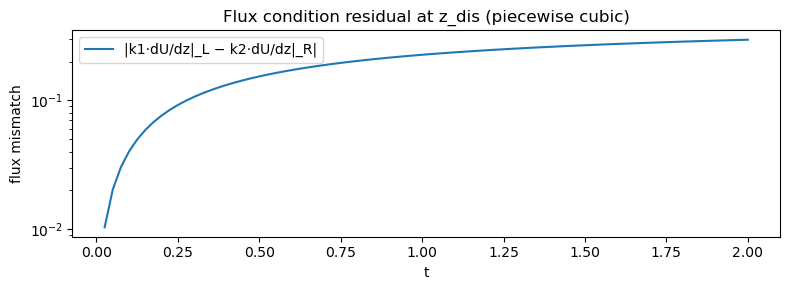

In [10]:
k1, k2, z_dis_val = sol._p['k1'], sol._p['k2'], sol._p['z_dis']
t_grid = sol['t']
eps    = 1e-6    # tiny offset to stay strictly inside each side

# evaluate dU/dz just left and just right of z_dis
z_L = torch.full_like(t_grid, z_dis_val - eps)
z_R = torch.full_like(t_grid, z_dis_val + eps)

dUdz_L = sol['interp_pw'](z_L, t_grid, dx=1)   # from left spline
dUdz_R = sol['interp_pw'](z_R, t_grid, dx=1)   # from right spline

flux_L = k1 * dUdz_L
flux_R = k2 * dUdz_R
flux_err = (flux_L - flux_R).abs()

print(f'Flux condition error  max={flux_err.max():.3e}  mean={flux_err.mean():.3e}')

fig, ax = plt.subplots(figsize=(8, 3))
ax.semilogy(t_grid.cpu(), flux_err.cpu(), label='|k1·dU/dz|_L − k2·dU/dz|_R|')
ax.set_xlabel('t'); ax.set_ylabel('flux mismatch')
ax.set_title('Flux condition residual at z_dis (piecewise cubic)')
ax.legend(); plt.tight_layout(); plt.show()

## Error comparison: linear vs cubic vs piecewise cubic

Coarse solve + all three interpolants evaluated on the fine grid.

In [11]:
nz_c, nz_f = 80, 640

print('Running coarse solver...')
sol_c = Solver(k1=1.0, k2=2.0, z_dis=1.0, Pda=1.0,
               Lz=16.0, nz=nz_c, tf=2.0, n_t_out=80,
               device=device, verbose=False)

print('Running fine reference solver...')
sol_f = Solver(k1=1.0, k2=2.0, z_dis=1.0, Pda=1.0,
               Lz=16.0, nz=nz_f, tf=2.0, n_t_out=80,
               device=device, verbose=False)
print('Done.')

Running coarse solver...
Running fine reference solver...
Done.


In [12]:
z_f   = sol_f['z']
t_out = sol_f['t']
U_ref = sol_f['U']

z_f2d, t_f2d = torch.meshgrid(z_f, t_out, indexing='ij')

U_lin = sol_c['interp_lin'](z_f2d, t_f2d)
U_cub = sol_c['interp'    ](z_f2d, t_f2d)
U_pw  = sol_c['interp_pw' ](z_f2d, t_f2d)

err_lin = (U_lin - U_ref).abs()
err_cub = (U_cub - U_ref).abs()
err_pw  = (U_pw  - U_ref).abs()

for name, err in [('Linear', err_lin), ('Cubic', err_cub), ('Piecewise', err_pw)]:
    print(f'{name:12s}  max={err.max():.3e}  mean={err.mean():.3e}')

Linear        max=3.355e-03  mean=1.490e-04
Cubic         max=3.731e-03  mean=2.073e-04
Piecewise     max=3.355e-03  mean=1.958e-04


## Plots

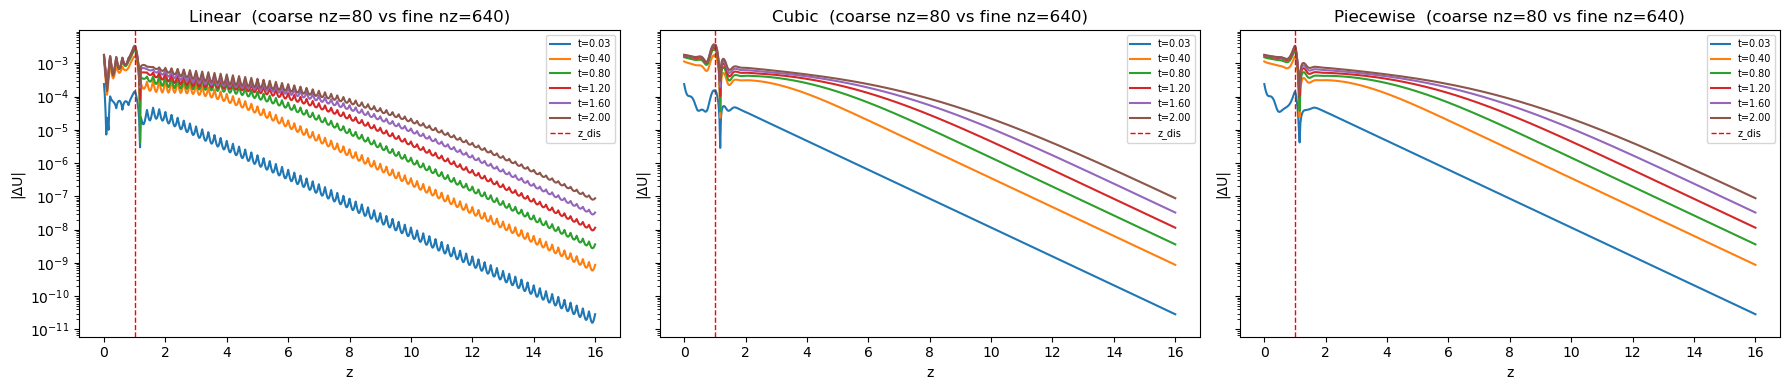

In [13]:
idx   = torch.linspace(0, 79, 6).long()
z_cpu = z_f.cpu(); t_cpu = t_out.cpu()

fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=True)
for ax, (name, err) in zip(axes, [('Linear',    err_lin),
                                   ('Cubic',     err_cub),
                                   ('Piecewise', err_pw)]):
    for i in idx:
        ax.semilogy(z_cpu, err.cpu()[:, i].clamp(min=1e-16),
                    label=f't={t_cpu[i]:.2f}')
    ax.axvline(1.0, color='r', linestyle='--', lw=1.0, label='z_dis')
    ax.set_xlabel('z'); ax.set_ylabel('|ΔU|')
    ax.set_title(f'{name}  (coarse nz={nz_c} vs fine nz={nz_f})')
    ax.legend(fontsize=7)
plt.tight_layout(); plt.show()

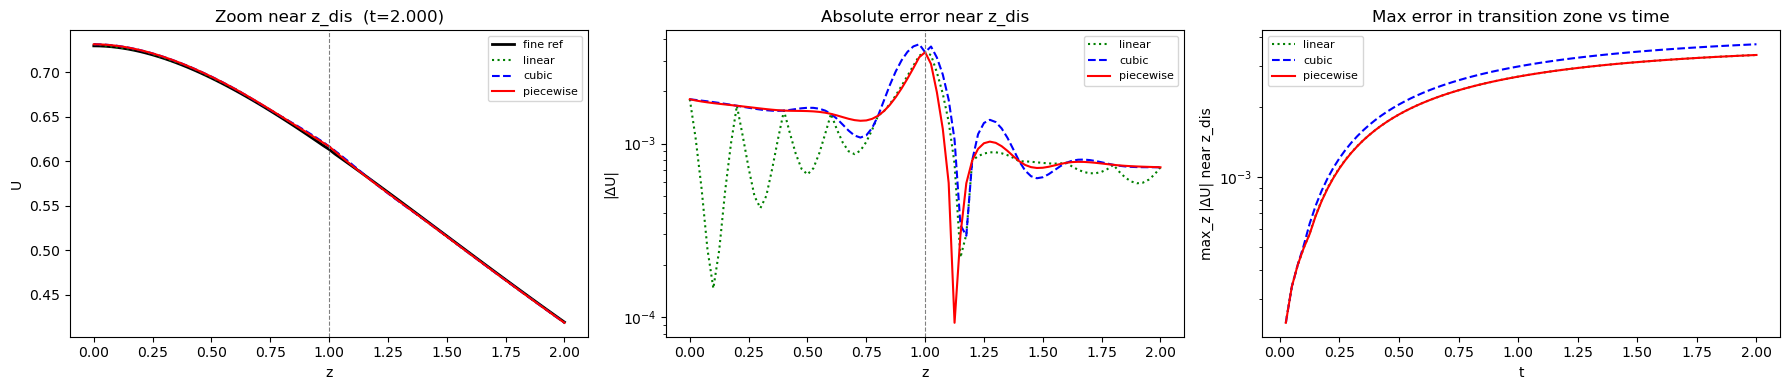

In [14]:
w   = nz_f // 16
m_f = torch.searchsorted(z_f, torch.tensor(1.0, device=z_f.device)).item()
sl  = slice(max(0, m_f - w), min(len(z_f), m_f + w + 1))
z_z = z_f[sl].cpu()
i_last = 79

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# panel 0: solutions
ax = axes[0]
ax.plot(z_z, U_ref[sl, i_last].cpu(), 'k-',  lw=2,   label='fine ref')
ax.plot(z_z, U_lin[sl, i_last].cpu(), 'g:',  lw=1.5, label='linear')
ax.plot(z_z, U_cub[sl, i_last].cpu(), 'b--', lw=1.5, label='cubic')
ax.plot(z_z, U_pw [sl, i_last].cpu(), 'r-',  lw=1.5, label='piecewise')
ax.axvline(1.0, color='gray', linestyle='--', lw=0.8)
ax.set_xlabel('z'); ax.set_ylabel('U')
ax.set_title(f'Zoom near z_dis  (t={t_cpu[i_last]:.3f})')
ax.legend(fontsize=8)

# panel 1: absolute error near z_dis
ax = axes[1]
for name, err, ls in [('linear', err_lin, 'g:'), ('cubic', err_cub, 'b--'), ('piecewise', err_pw, 'r-')]:
    ax.semilogy(z_z, err[sl, i_last].cpu().clamp(min=1e-16), ls, label=name)
ax.axvline(1.0, color='gray', linestyle='--', lw=0.8)
ax.set_xlabel('z'); ax.set_ylabel('|ΔU|')
ax.set_title('Absolute error near z_dis')
ax.legend(fontsize=8)

# panel 2: max error in transition zone vs time
ax = axes[2]
for name, err, ls in [('linear', err_lin, 'g:'), ('cubic', err_cub, 'b--'), ('piecewise', err_pw, 'r-')]:
    ax.semilogy(t_cpu, err[sl, :].max(dim=0).values.cpu(), ls, label=name)
ax.set_xlabel('t'); ax.set_ylabel('max_z |ΔU| near z_dis')
ax.set_title('Max error in transition zone vs time')
ax.legend(fontsize=8)

plt.tight_layout(); plt.show()

## Save dataset

In [ ]:
p        = sol._p
out_file = f'./data/2layer_k1{p["k1"]}_k2{p["k2"]}_nz{p["nz"]}.pt'
sol.save(out_file)